In [ ]:
!pip install koreanize-matplotlib -q
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# 데이터 전처리(데이터 분리, 스케일링, 인코딩, 파이프라인(데이터 누수 방지))관련
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# 모델 학습 및 성능평가 관련
from xgboost import XGBRegressor, plot_importance
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score # (y_true, y_pred, sample_weight(Default=None))

# Optuna 관련
import optuna
from optuna import Trial
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour
)
# Optuna 로깅 레벨 조정
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 랜덤 시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Optuna 버전: {optuna.__version__}")

Optuna 버전: 4.7.0


#1. 데이터 로드 및 확인

In [ ]:
# 데이터 로드 & 확인
# train 데이터
calories_data = pd.read_csv("/content/final_train_adj.csv")
calories_data.columns = [c.strip() for c in calories_data.columns]    # 컬럼명 앞뒤 공백 제거

# 해당 csv의 컬럼명으로 변경 필요
calories_data = calories_data[[
    "ex_dura", "bpm", "body_temp", "hr_ratio", "age", "gender",
    "height_cm", "weight_kg", "bmi", "log_exercise_stress_index",
    "log_bsa_intensity_time", "calories_burned"
    ]].copy()

print(calories_data.shape)    # (7500, 12)
display(calories_data.info())

# 중복 데이터 확인
dup_rows = calories_data[calories_data.duplicated(keep=False)]
print(f"중복 확인:\n{dup_rows}")
print("중복 개수:", calories_data.duplicated().sum())

# 중복 샘플 드랍
calories_data = calories_data.drop_duplicates(keep="first")
print("남아있는 중복 개수:", calories_data.duplicated().sum())


(7500, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ex_dura                    7500 non-null   float64
 1   bpm                        7500 non-null   float64
 2   body_temp                  7500 non-null   float64
 3   hr_ratio                   7500 non-null   float64
 4   age                        7500 non-null   int64  
 5   gender                     7500 non-null   object 
 6   height_cm                  7500 non-null   float64
 7   weight_kg                  7500 non-null   float64
 8   bmi                        7500 non-null   float64
 9   log_exercise_stress_index  7500 non-null   float64
 10  log_bsa_intensity_time     7500 non-null   float64
 11  calories_burned            7500 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 703.3+ KB


None

중복 확인:
      ex_dura   bpm  body_temp  hr_ratio  age gender  height_cm  weight_kg  \
4251      9.0  90.0       39.5   0.46875   28      F      165.1  59.012319   
4662      9.0  90.0       39.5   0.46875   28      F      165.1  59.012319   

        bmi  log_exercise_stress_index  log_bsa_intensity_time  \
4251  21.65                   2.446415                2.071949   
4662  21.65                   2.446415                2.071949   

      calories_burned  
4251             40.0  
4662             40.0  
중복 개수: 1
남아있는 중복 개수: 0


#2. 데이터 분할_X / y 분리

In [ ]:
# X, y 분리
X = calories_data.drop(columns=['calories_burned']).copy()
y = calories_data['calories_burned'].copy()

# train, validation 분리
# 이상치 데이터 flag 정의
# 체온 >= 41 이고 bpm < 100.0 이면 outlier_flag=1
outlier_flag = ((calories_data["body_temp"] >= 41) & (calories_data["bpm"] < 100.0)).astype(int)

X_train, X_valid, y_train, y_valid, flag_train, flag_valid = train_test_split(
    X, y, outlier_flag,
    test_size=0.2,
    random_state=42,
    stratify=outlier_flag
)

# 분리된 형태 확인
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape, flag_train.shape, flag_valid.shape

((5999, 11), (1500, 11), (5999,), (1500,), (5999,), (1500,))

#3. 파이프라인

In [ ]:
# -------------------------
# 1) 전처리 파이프라인 (수치 스케일링 + 범주 원핫)
# -------------------------

# 수치/범주 컬럼 지정 (직접 넣는 게 가장 안전)
num_cols = [
    "ex_dura", "bpm", "body_temp", "hr_ratio", "age",
    "height_cm", "weight_kg", "bmi", "log_exercise_stress_index",
    "log_bsa_intensity_time"  # 예시임 데이터에 맞게 변경 필요
]
cat_cols = [
    "gender"  # 예시임 데이터에 맞게 변경 필요
]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"  # 나머지 컬럼 버릴지/통과시킬지 선택: "passthrough"도 가능
)

# -------------------------
# 2) 모델 파이프라인
# -------------------------
svr_reg = SVR(kernel="rbf")

svr_pipe = Pipeline(steps=[
    ("preprocessor", preprocess),   # 기존 ColumnTransformer 유지
    ("model", svr_reg)
])

#4. baseline 모델 학습 및 평가

In [ ]:
# 이상치 데이터가 있는 행 가중치 조정
def make_sample_weight(df, temp_col="body_temp", bpm_col="bpm"):
    # 기본은 전부 1.0
    w = np.ones(len(df), dtype=float)

    # 이상치로 의심되는 조합: temp >= 41 & bpm < 100
    mask_suspect = (df[temp_col] >= 41) & (df[bpm_col] < 100.0)

    # 가중치 낮추기(ex: 0.5. ~ 0.7 조정 가능!)
    w[mask_suspect] = 0.5

    return w, mask_suspect

w_train, mask_train = make_sample_weight(X_train, temp_col="body_temp", bpm_col="bpm")

# 모델 학습
print("모델 학습중...")
svr_pipe.fit(X_train, y_train, model__sample_weight=w_train)    # 'sample_weight=w_train'의 의미: 정상적인 행은 가중치 1로 되고, 이상치 행만 0.5로 적용!
print("모델 학습 완료!🎉")

모델 학습중...
모델 학습 완료!🎉


In [ ]:
# 베이스 모델 예측 및 평가
y_preds = svr_pipe.predict(X_valid)

mse = mean_squared_error(y_valid, y_preds)
rmse = root_mean_squared_error(y_valid, y_preds)

print(f"y의 평균: {y_train.mean():.2f}")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

y의 평균: 89.61
MSE (Mean Squared Error): 74.47
RMSE (Root Mean Squared Error): 8.63


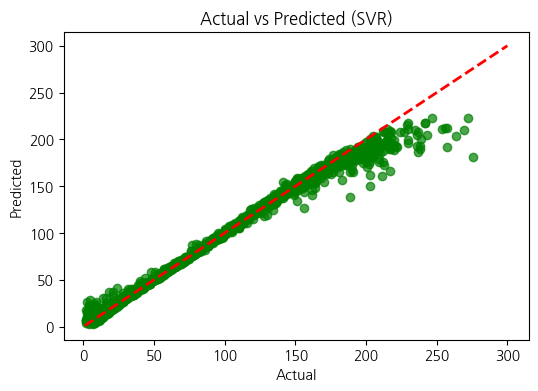

In [ ]:
# (시각화) 실제값 vs 예측값 비교
plt.figure(figsize=(6, 4))
plt.scatter(y_valid, y_preds, alpha=0.7, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 대각선 (완벽한 예측선)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (SVR)")
plt.show()

In [ ]:
# 검증 데이터 결과 분석(이상치 영향)
rmse_all = root_mean_squared_error(y_valid, y_preds)

valid_df = X_valid.loc[X_valid.index]
mask_valid = (valid_df["body_temp"] >= 41) & (valid_df["bpm"] < 100.0)

rmse_subset = (
    root_mean_squared_error(y_valid[mask_valid], y_preds[mask_valid])
    if mask_valid.any() else np.nan
)

print("RMSE_all:", rmse_all)
print("RMSE_subset(temp>=41 & bpm<100.0):", rmse_subset, " | n=", int(mask_valid.sum()))


RMSE_all: 8.62943026530681
RMSE_subset(temp>=41 & bpm<100.0): 4.584817623250425  | n= 8


In [ ]:
#2. SVR Regression(베이스라인 모델)
# 가중치 0.5 결과
# y의 평균: 89.61
# MSE (Mean Squared Error): 74.47
# RMSE (Root Mean Squared Error): 8.63
# RMSE_subset(temp>=41 & bpm<100.0): 4.584817623250425  | n= 8

# 가중치 0.7 결과

# 가중치 0.3 결과


# Optuna로 최적화

In [ ]:
print("\n" + "="*60)
print(" SVR Optuna 최적화")
print("="*60)

# 1) sample_weight: 기본 1.0, outlier만 0.5
def make_sample_weight_from_flag(flag, w_bad=0.5):
    w = np.ones(len(flag), dtype=float)
    w[np.asarray(flag) == 1] = w_bad
    return w

# 2) StratifiedKFold (회귀지만 flag 기준 stratify)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective_svr(trial):

    # 🔥 SVR 전용 파라미터 탐색
    params = {
        "C": trial.suggest_float("C", 1, 1e3, log=True),
        "epsilon": trial.suggest_float("epsilon", 1e-4, 5e-2, log=True),
        "gamma": trial.suggest_float("gamma", 1e-3, 2e-1, log=True),
        "kernel": "rbf"
    }


    rmses = []

    for tr_idx, va_idx in skf.split(X_train, flag_train):

        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        # train fold에만 sample_weight 적용
        w_tr = make_sample_weight_from_flag(flag_train.iloc[tr_idx], w_bad=0.5)

        # 🔥 fold마다 전처리 다시 fit (데이터 누수 방지)
        X_tr_processed = preprocess.fit_transform(X_tr)
        X_va_processed = preprocess.transform(X_va)

        model = SVR(**params)

        model.fit(
            X_tr_processed,
            y_tr,
            sample_weight=w_tr
        )

        pred = model.predict(X_va_processed)

        rmse = np.sqrt(mean_squared_error(y_va, pred))
        rmses.append(rmse)

    return float(np.mean(rmses))


# Study 생성 및 최적화
study_svr = optuna.create_study(
    direction="minimize",
    study_name="svr_regression_weighted"
)

study_svr.optimize(objective_svr, n_trials=50, show_progress_bar=True)

print("Best RMSE:", study_svr.best_value)
print("Best params:", study_svr.best_params)



 SVR Optuna 최적화


  0%|          | 0/50 [00:00<?, ?it/s]

Best RMSE: 0.36066107881593423
Best params: {'C': 992.9682470240032, 'epsilon': 0.006664035966340519, 'gamma': 0.026309005107614036}


In [ ]:
# 1) Optuna 파라미터 중요도
import optuna.visualization as vis

vis.plot_param_importances(study_svr)


In [ ]:
# 1. 최적 파라미터 가져오기
best_params = study_svr.best_params

# 2. 최종 모델 생성
final_model = SVR(**best_params)

# 3. 전체 train으로 재학습
X_train_processed = preprocess.fit_transform(X_train)
X_valid_processed = preprocess.transform(X_valid)

w_train = make_sample_weight(X_train)[0]

final_model.fit(
    X_train_processed,
    y_train,
    sample_weight=w_train
)

SVR(C=992.9682470240032, epsilon=0.006664035966340519,
    gamma=0.026309005107614036)

In [ ]:
pred_valid = final_model.predict(X_valid_processed)

rmse_valid = np.sqrt(mean_squared_error(y_valid, pred_valid))

print("Optuna CV RMSE:", study_svr.best_value)
print("Holdout RMSE:", rmse_valid)

Optuna CV RMSE: 0.36066107881593423
Holdout RMSE: 0.336229203335142


In [ ]:
# 4. validation/test 평가
X_valid_processed = preprocess.transform(X_valid)

y_pred = final_model.predict(X_valid_processed)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print("Final Validation RMSE:", rmse)

Final Validation RMSE: 0.336229203335142


In [ ]:
# CV 성능과 비교
print("Optuna CV RMSE:", study_svr.best_value)
print("Holdout RMSE:", rmse)

# R²확인
r2 = r2_score(y_valid, y_pred)
print("Validation R2:", r2)

Optuna CV RMSE: 0.36066107881593423
Holdout RMSE: 0.336229203335142
Validation R2: 0.9999721971632327


In [ ]:
# 이상치 subset 성능 확인 (이미 구조 있음 👍)
mask_valid = (X_valid["body_temp"] >= 41) & (X_valid["bpm"] < 100.0)

rmse_subset = (
    np.sqrt(mean_squared_error(y_valid[mask_valid], y_pred[mask_valid]))
    if mask_valid.any() else np.nan
)

print("RMSE_all:", rmse)
print("RMSE_subset:", rmse_subset)

RMSE_all: 0.336229203335142
RMSE_subset: 0.6092936942940508


In [ ]:
# ① CV vs Holdout 비교
print("Optuna CV RMSE:", study_svr.best_value)
print("Holdout RMSE:", rmse)

Optuna CV RMSE: 0.36066107881593423
Holdout RMSE: 0.336229203335142


# GridSearchCV

In [ ]:
# 1) outlier flag -> sample_weight (flag=1이면 0.5)
def make_sample_weight_from_flag(flag, w_bad=0.5):
    w = np.ones(len(flag), dtype=float)
    w[np.asarray(flag) == 1] = w_bad
    return w

# 이상치 샘플 가중치 조정
w_train = make_sample_weight_from_flag(flag_train, w_bad=0.5)

# 2) StratifiedKFold를 "flag 기준"으로 split 생성
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(skf.split(X_train, flag_train))

# 3) 인코딩
cat_cols = ["gender"]  # 범주형 컬럼 지정
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# 4) 하이퍼파라미터 그리드

pipe = Pipeline([
    ("prep", preprocess),
    ("model", SVR(kernel="rbf")),
])

# 2) Optuna best
C_best = 1390.1555458336043
g_best = 0.02104720408609123
e_best = 0.009996053949510779

# 3) 얇은 그리드
C_grid = [C_best * m for m in [0.5, 1.0, 1.5]]
g_grid = [g_best * m for m in [0.5, 1.0, 1.5]]
e_grid = [e_best * m for m in [0.5, 1.0, 1.5]]

param_grid = {
    "model__C": C_grid,
    "model__epsilon": e_grid,
    "model__gamma": g_grid
}

In [ ]:
# GridSearchCV
print("\nTuning SVR...")
print("(교차검증 수행 중...)\n")

gscv = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_splits,              # <- flag stratify 적용된 split
    n_jobs=-1,
    verbose=2
)

# 5) sample_weight는 Pipeline의 "model step"에 전달해야 함
gscv.fit(X_train, y_train, model__sample_weight=w_train)

print("Best RMSE:", -gscv.best_score_)
print("Best params:", gscv.best_params_)
print("\nGridSearchCV 완료!")


Tuning SVR...
(교차검증 수행 중...)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


In [ ]:
# 최적 모델, 파라미터 추출
best_reg = gscv.best_estimator_
best_param = gscv.best_params_

print("[최적화 결과]")
print(f"Best R2 Score (Train CV): {gscv.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in gscv.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best R2 Score (Train CV): -0.3378

Best Parameters:
  model__C: 2085.2333187504064
  model__epsilon: 0.014994080924266167
  model__gamma: 0.02104720408609123


In [ ]:
# 상위 3개 결과
cv_results = pd.DataFrame(gscv.cv_results_)
top_results = cv_results.nlargest(3, 'mean_test_score')[[
    'param_model__C',
    'param_model__epsilon',
    'param_model__gamma',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 3개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 3개 파라미터 조합:
 param_model__C  param_model__epsilon  param_model__gamma  mean_test_score  std_test_score
    2085.233319              0.014994            0.021047        -0.337840        0.013846
    2085.233319              0.009996            0.021047        -0.337957        0.013571
    2085.233319              0.004998            0.021047        -0.337974        0.013200


In [ ]:
# 테스트 데이터 예측
best_params = {
    "C": 1390.1555458336043,
    "epsilon": 0.009996053949510779,
    "gamma": 0.02104720408609123,
    "kernel": "rbf"
}

final_model = SVR(**best_params)

# 3. 전체 train으로 재학습
X_train_processed = preprocess.fit_transform(X_train)
X_valid_processed = preprocess.transform(X_valid)

w_train = make_sample_weight(X_train)[0]

final_model.fit(
    X_train_processed,
    y_train,
    sample_weight=w_train
)

y_pred = final_model.predict(X_valid_processed)

# 평가 지표 계산
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

print(f"Valid RMSE: {rmse:.4f}")
print(f"Valid R2 Score: {r2:.4f}")

Valid RMSE: 0.3318
Valid R2 Score: 1.0000


In [ ]:
# 과적합 여부 확인: CV RMSE는 좋은데 holdout RMSE가 확 튄다 → 과적합 가능성↑. 비슷하면 문제 없음
pred_valid = final_model.predict(X_valid_processed)
rmse_valid = np.sqrt(np.mean((y_valid - pred_valid)**2))
print(f"Holdout RMSE: {rmse_valid}")

Holdout RMSE: 0.3317870311221427


# 테스트 데이터 예측 및 저장

In [ ]:
# 테스트 데이터 로드
calories_test_data = pd.read_csv("/content/final_test.csv")
calories_test_data.columns = [c.strip() for c in calories_test_data.columns]    # 컬럼명 앞/뒤 공백 제거
X_test = calories_test_data

# 데이터 확인
print(f"데이터 크기: {X_test.shape}")
display(X_test.info())
dup_rows = X_test[X_test.duplicated(keep=False)]
print(f"중복 확인:\n{dup_rows}")

데이터 크기: (7500, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ex_dura                    7500 non-null   float64
 1   bpm                        7500 non-null   float64
 2   body_temp                  7500 non-null   float64
 3   hr_ratio                   7500 non-null   float64
 4   age                        7500 non-null   int64  
 5   gender                     7500 non-null   object 
 6   height_cm                  7500 non-null   float64
 7   weight_kg                  7500 non-null   float64
 8   bmi                        7500 non-null   float64
 9   log_exercise_stress_index  7500 non-null   float64
 10  log_bsa_intensity_time     7500 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 644.7+ KB


None

중복 확인:
Empty DataFrame
Columns: [ex_dura, bpm, body_temp, hr_ratio, age, gender, height_cm, weight_kg, bmi, log_exercise_stress_index, log_bsa_intensity_time]
Index: []


In [ ]:
# 테스트 데이터 예측
X_test_processed = preprocess.transform(X_test)
final_pred = final_model.predict(X_test_processed)

In [ ]:
# 제출 파일 제작
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = final_pred
submission.to_csv('./submit.csv', index = False, encoding="utf-8")